# Enhanced Combined Drought Index - Precipitation Drought Index

* **Products used:** 
[rainfall_chirps_daily](https://explorer.digitalearth.africa/products/rainfall_chirps_daily),
[ls5_st](https://explorer.digitalearth.africa/products/ls5_st),
[ls8_st](https://explorer.digitalearth.africa/products/ls8_st),
[ls9_st](https://explorer.digitalearth.africa/products/ls9_st),
[ls5_sr](https://explorer.digitalearth.africa/products/ls5_sr),
[ls8_sr](https://explorer.digitalearth.africa/products/ls8_sr),
[ls9_sr](https://explorer.digitalearth.africa/products/ls9_st),
[s2_l2a](https://explorer.digitalearth.africa/products/s2_l2a),

## Background 

Drought is an extended period, during which, fresh water availability and accessibility for the ecosystem at a given time and place is below normal, due to unfavourable spatial and temporal distribution of rainfall, temperature, soil moisture and wind characteristics [(Balint et al., 2013)](https://doi.org/10.1016/B978-0-444-59559-1.00023-2). Severe droughts can affect large populations, leading to a long-term threat to people’s livelihoods and result in tremendous economic loss [(Enenkel et al., 2016)](https://doi.org/10.3390/rs8040340).

The Enhanced Combined Drought Index aims at the timely and reliable detection of drought events with regard to their spatio-temporal extent and severity. The Enhanced Drought Index is a combination of the following: a precipitation component, which considers rainfall deficits and dryness persistence; a soil moisture component, which considers soil moisture deficits and deficit persistence; a vegetation component which considers NDVI deficits and deficit persistence; and a temperature component, which considers temperature excesses and persistence of high temperatures. The index uses satellite-derived rainfall, soil moisture, land surface temperature and vegetation status as input datasets. [(Enenkel et al., 2016)](https://doi.org/10.3390/rs8040340)

The drought index calculated using the precipitation component is referred as the **Precipitation Drought Index (PDI)**, while the index based on temperature is named as **Temperature Drought Index (TDI)**, the index based on soil moisture is named as the **Soil Moisture Drought Index** and that based on the vegetation component is named as **Vegetation Drought Index (VDI)**.

Each drought index can be expressed as:

$\text{Drought Index} = \frac{\text{Actual Average for Interest Period}}{\text{Long Term Average for Interest Period}} * \sqrt{\frac{\text{Actual Length of Continuous Deficit or Excess in the Interest Period}}{\text{Long Term Average of Continuous Deficit or Excess in the Interest Period}}}$

Each drought index is calculated similarly. The equation below illustrates the calculation of the ECDI precipitation component:

\begin{equation}
\text{PDI}_{y,d} = \frac{
\frac{1}{\text{IP}} \sum_{j=0}^{\text{IP} - 1} P^*_{y,(d-j)}}{\frac{1}{n}\sum_{k=1}^n[\frac{1}{\text{IP}} \sum_{j=0}^{\text{IP} - 1} P^*_{(d-j), k}]} * \sqrt{\frac{(\text{RL}^*)P^*_{d, y}}{\frac{1}{n}\sum_{k=1}^{n}(\text{RL}^*)P^*_{d, k}}}
\end{equation}

- $\text{PDI}_{y,d}$ is the Precipitation Drought Index for year $\text{y}$ and time unit (dekad/month) $\text{d}$

- $P^*$ is the modified dekadal/monthly precipitation average 

- $\text{RL}*$ is the modified run length parameter 

- $\text{RL*}(P*)$ (run length) is the maximum number of successive dekads/months below the long-term average rainfall in the interest period
> **Note**: For temperature, run length is the maximum number of successive dekads/months above the long-term average temperature in the interest period

- $\text{IP}$ is the interest period (e.g. 3, 4, 5, . . . dekads/months) (longer IPs detect more severe drought events). IP is flexible defines to what extent past observations are considered.

- $n$ is the number of years where relevant data are available,

- $j$ is the summation running parameter covering the Interest Period

- $k$ is the summation parameter covering the years where relevant data are available

- $d$ time unit (dekad or month) 

- $y$ year

The raw time series of temperature and precipitation as well as the run length are modified to adjust the range of all variables and to avoid a division by zero.

\begin{equation}
T^* = (T_{max} + 1) - T
\end{equation}

\begin{equation}
P^* = P + 1
\end{equation}

\begin{equation}
\text{RL}^* = (\text{RL}_{max} + 1) - \text{RL}
\end{equation}

\begin{equation}
\text{NDVI}^* = \text{NDVI} - (\text{NDVI}_{min} -0.01)
\end{equation}


- $T^*$ is the modified dekadal/monthly temperature average 
- $P^*$ is the modified dekadal/monthly precipitation average 
- $\text{RL}^*$ is the modified run length

All the individual drought indices differ in range. To improve their interpretability and visual comparability a simple scaling factor is introduced.

\begin{equation}
PDI_{scaled} = \frac{(PDI - PDI_{min})}{(PDI_{max} - PDI_{min})}
\end{equation}

The weight of each individual drought index is automatically calculated for every grid point (pixel) with respect to its capability to reflect the future vegetation status (NDVI) and multiplied by the respective individual index to calculate the ECDI. In the case of data gaps in one input dataset, the weights are automatically redistributed to other available variables.

\begin{equation}
ECDI = \sum_{i-1}^{n}w_{i} * \text{DI}_{i}
\end{equation}

- $ECDI$ Enhanced Combined Drought Index 

- $w$ Weight for each individual drought index (e.g., rainfall)

- $\text{DI}$ Individual drought index 

- $n$ number of drought indices used to calculate the ECDI 

- $i$ running parameter covering the number of drought indices

\begin{equation}
w_{i} = \frac{\frac{lag^*_{i}}{\sum_{j=1}^{n} lag^*_{j}} + \frac{corr^*_{i}}{\sum_{j=1}^{n} corr^*_{j}}}{2}
\end{equation}

- $w$ weight for the respective drought index 

- $lag^*$ modified time lag for the respective parameter 

- $corr^*$ modified correlation coefficient for the respective parameter 

- $i$ index for the respective parameter/drought index 

- $j$ running parameter covering all parameters used for the ECDI calculation

- $n$ number of individual drought indices used for the ECDI calculation

## Description



The notebook outlines:

***

## Getting started

To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages


In [1]:
%matplotlib inline
import os
import calendar
from datetime import datetime
import datacube
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datacube.utils.geometry import Geometry, CRS
from datacube.utils.cog import write_cog
from deafrica_tools.spatial import xr_rasterize
from deafrica_tools.dask import create_local_dask_cluster

from drought_index import resample_ds, calculate_drought_index

### Set up a Dask cluster

Dask can be used to better manage memory use and conduct the analysis in parallel. 
For an introduction to using Dask with Digital Earth Africa, see the [Dask notebook](../../Beginners_guide/08_Parallel_processing_with_dask.ipynb).

>**Note**: We recommend opening the Dask processing window to view the different computations that are being executed; to do this, see the *Dask dashboard in DE Africa* section of the [Dask notebook](../../Beginners_guide/08_Parallel_processing_with_dask.ipynb).

To use Dask, set up the local computing cluster using the cell below.

In [2]:
# Setup a dask cluster.
create_local_dask_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/victoria@kartoza.com/proxy/8787/status,
Dashboard: /user/victoria@kartoza.com/proxy/8787/status,Workers: 1
Total threads: 15,Total memory: 97.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:40997,Workers: 1
Dashboard: /user/victoria@kartoza.com/proxy/8787/status,Total threads: 15
Started: Just now,Total memory: 97.21 GiB
Comm: tcp://127.0.0.1:40259,Total threads: 15
Dashboard: /user/victoria@kartoza.com/proxy/37019/status,Memory: 97.21 GiB
Nanny: tcp://127.0.0.1:45211,


### Analysis parameters

The following cell sets important parameters for the analysis:

* `vector_file`: file path for the shapefile containing polygons for the boundaries of Africa countries
* `attribute_col`: The column in the "vector_file" containing the country names.
* `county`: In this analysis, we'll select a Kenyan County to mask the dataset and analysis.
* `resolution`: The x and y cell resolution of the satellite data in metres (spatial resolution). We'll use 5,000 m, which is approximately equal to the default CHIRPS resolution.
* `output_crs` : The coordinate reference system that the loaded data is to be reprojected to.
* `dask_chunks`:  the size of the dask chunks, dask breaks data into manageable chunks that can be easily stored in memory, e.g. `dict(x=1000,y=1000)`
* `time_range` : Time range to load data for.
* `output_dir` :  The directory in which to store results from the analysis.
* `min_num_obs` : The minimum number of clear observations for creating a quality assurance mask for the NDVI climatology. The minimum number of clear observations should be ~20-30 observations.
* `y` : The year to calculate the drought index for 
* `month` : The month in the year `y` to calculate the drought index for
* `dekad_no_in_month` : The dekad in the month `m` to calculate the drought index for. Each month has 3 dekads with the first dekad (1) running from the 1st to the 10th, the second dekad running from the 11th to the 20th and the 3rd from the 21st to the last day of the month. 
* `ip` : The interest period to use to calculate the drought indices e.g. (3, 4, 5 dekads). It defines to what extent past observations are considered. Longer IPs detect more severe drought events. For example, if the IP=3 dekads, then the drought index (say PDI) of 0.35 for dekad 2 of 2006 implies actual drought for dekad 36 of 2005, dekad 1 of 2006 and dekad 2 of 2006.

**If running the notebook for the first time**, keep the default settings below.
This will demonstrate how the analysis works and provide meaningful results.

In [3]:
vector_file = "https://raw.githubusercontent.com/digitalearthafrica/deafrica-sandbox-notebooks/main/Supplementary_data/Rainfall_anomaly_CHIRPS/african_countries.geojson"
attribute_col = "COUNTRY"
country = "Ethiopia"

resolution = (-5000, 5000)
output_crs = "EPSG:6933"

time_range = ("1981","2024")

y = 2000
month = 10
dekad_no_in_month = 2
d = ((month - 1) * 3) + dekad_no_in_month
ip = 18 # Equivalent to an interest period of 6 months
print(f"Calculating the drought index for the year {y} and dekad {d} using an interest period of {ip} dekads.")

Calculating the drought index for the year 2000 and dekad 29 using an interest period of 18 dekads.


In [4]:
# Create the output directory if it does not exist.
output_directory = "results"
os.makedirs(output_directory, exist_ok=True)

In [5]:
# Get the country geometry.
country_name = "Ethiopia"
african_countries = gpd.read_file(vector_file)
country = african_countries[african_countries[attribute_col] == country_name].take([0])
country_geom = Geometry(geom=country.geometry.iloc[0], crs=african_countries.crs)

# Select a county.
#county_name = "Embu"
#kenya_counties = gpd.read_file("Kenya_Counties.geojson")
#county = kenya_counties[kenya_counties["COUNTY_NAME"] == county_name].take([0])
#county_geom = Geometry(geom=county.geometry.iloc[0], crs=kenya_counties.crs)

### Connect to the datacube

Connect to the datacube so we can access DE Africa data.
The `app` parameter is a unique name for the analysis which is based on the notebook file name.

In [6]:
dc = datacube.Datacube(app='StandardizedPrecipitationIndex')

## Load the input datasets. 

In [7]:
# Create a datacube query object.
query = {"geopolygon": country_geom,
         "output_crs": output_crs,
         "resolution": resolution,
         "dask_chunks" : dict(time=120, x=50000, y=50000),
         "time": time_range,
        }

In [8]:
%%time
# Load all the rainfall data available for the area of interest.
ds_rf = dc.load(product="rainfall_chirps_daily",
                measurements=['rainfall'], 
                **query)

# xarray.Dataset to DataArray.
da_rf = ds_rf.rainfall

# Set no data values to nan
da_rf = da_rf.where(da_rf !=-9999.)
da_rf

CPU times: user 2min 32s, sys: 42.3 s, total: 3min 14s
Wall time: 2min 28s


<xarray.DataArray 'rainfall' (time: 15644, y: 291, x: 290)>
dask.array<where, shape=(15644, 291, 290), dtype=float32, chunksize=(120, 291, 290), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 1981-01-01T11:59:59.500000 ... 2023-11...
  * y            (y) float64 1.882e+06 1.878e+06 ... 4.375e+05 4.325e+05
  * x            (x) float64 3.182e+06 3.188e+06 ... 4.622e+06 4.628e+06
    spatial_ref  int32 6933
Attributes:
    units:         mm
    nodata:        -9999
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

In [9]:
%%time
da_rf_resampled = resample_ds(da_rf)
da_rf_resampled

/usr/local/lib/python3.10/dist-packages/rasterio/warp.py:344: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  _reproject(


CPU times: user 54 s, sys: 2.3 s, total: 56.3 s
Wall time: 5min 13s


<xarray.DataArray 'rainfall' (time: 1542, y: 291, x: 290)>
array([[[0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [0.49171224, 0.5288862 , 0.5395447 , ...,        nan,
                nan,        nan],
        [0.37300593, 0.45871753, 0.52057016, ...,        nan,
                nan,        nan],
        [0.31084007, 0.41844183, 0.4950568 , ...,        nan,
                nan,        nan]],

       [[0.        , 0.        , 0.        , ..., 0.60119295,
         0.60295457, 0.5003017 ],
        [0.        , 0.        , 0.        , ..., 0.6919319 ,
         0.59597886, 0.5972334 ],
        [0.        , 0.        , 0.        , ..., 0.68437725,
         0.58973897, 0.5908141 ],
...
        [2.2595973 , 2.0259826 , 2.15068   , ...,        nan,
                nan,        nan],
        [1.7137829 , 1.6858876 , 2.185288  , ...,        nan,
                nan,        nan],
        [1.4459366 , 1.5616534 , 1.9773571 , ...,        nan,
                nan,        nan]],

       [[0.        , 0.        , 0.        , ..., 0.985587  ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , ..., 0.        ,
         0.        , 0.        ],
        ...,
        [1.3469812 , 1.2845949 , 1.6178836 , ...,        nan,
                nan,        nan],
        [1.1492127 , 1.1816232 , 1.6054903 , ...,        nan,
                nan,        nan],
        [1.0887913 , 1.2587265 , 1.5577506 , ...,        nan,
                nan,        nan]]], dtype=float32)
Coordinates:
  * y            (y) float64 1.882e+06 1.878e+06 ... 4.375e+05 4.325e+05
  * x            (x) float64 3.182e+06 3.188e+06 ... 4.622e+06 4.628e+06
    spatial_ref  int32 6933
  * time         (time) datetime64[ns] 1981-01-01 1981-01-11 ... 2023-11-21
Attributes:
    units:         mm
    nodata:        -9999
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

In [10]:
# Modify the raw timeseries of precipitation to adjust the range of
# all variables and to avoid a division by zero (Equation (3))
da_rf_modified =  da_rf_resampled + 1
da_rf_modified

<xarray.DataArray 'rainfall' (time: 1542, y: 291, x: 290)>
array([[[1.       , 1.       , 1.       , ..., 1.       , 1.       ,
         1.       ],
        [1.       , 1.       , 1.       , ..., 1.       , 1.       ,
         1.       ],
        [1.       , 1.       , 1.       , ..., 1.       , 1.       ,
         1.       ],
        ...,
        [1.4917122, 1.5288862, 1.5395447, ...,       nan,       nan,
               nan],
        [1.3730059, 1.4587176, 1.5205702, ...,       nan,       nan,
               nan],
        [1.3108401, 1.4184418, 1.4950569, ...,       nan,       nan,
               nan]],

       [[1.       , 1.       , 1.       , ..., 1.601193 , 1.6029546,
         1.5003017],
        [1.       , 1.       , 1.       , ..., 1.691932 , 1.5959789,
         1.5972334],
        [1.       , 1.       , 1.       , ..., 1.6843772, 1.589739 ,
         1.5908141],
...
        [3.2595973, 3.0259826, 3.15068  , ...,       nan,       nan,
               nan],
        [2.7137828, 2.6858876, 3.185288 , ...,       nan,       nan,
               nan],
        [2.4459367, 2.5616534, 2.9773571, ...,       nan,       nan,
               nan]],

       [[1.       , 1.       , 1.       , ..., 1.985587 , 1.       ,
         1.       ],
        [1.       , 1.       , 1.       , ..., 1.       , 1.       ,
         1.       ],
        [1.       , 1.       , 1.       , ..., 1.       , 1.       ,
         1.       ],
        ...,
        [2.346981 , 2.284595 , 2.6178837, ...,       nan,       nan,
               nan],
        [2.1492128, 2.1816232, 2.6054902, ...,       nan,       nan,
               nan],
        [2.0887914, 2.2587266, 2.5577507, ...,       nan,       nan,
               nan]]], dtype=float32)
Coordinates:
  * y            (y) float64 1.882e+06 1.878e+06 ... 4.375e+05 4.325e+05
  * x            (x) float64 3.182e+06 3.188e+06 ... 4.622e+06 4.628e+06
    spatial_ref  int32 6933
  * time         (time) datetime64[ns] 1981-01-01 1981-01-11 ... 2023-11-21

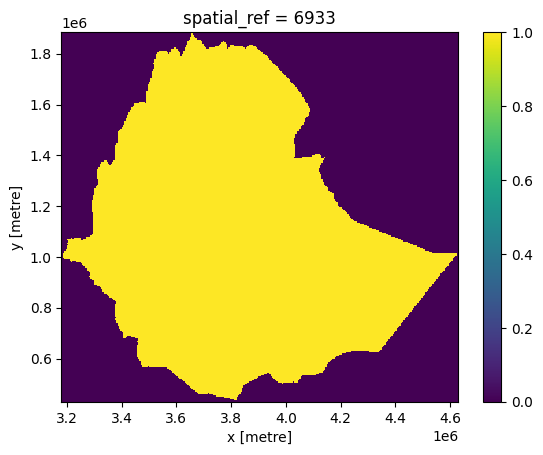

In [11]:
# Mask the data to the area of interest.
african_countries = african_countries.to_crs(output_crs)

mask = xr_rasterize(african_countries[african_countries[attribute_col] == country_name], da_rf_modified)

da_rf_modified = da_rf_modified.where(mask)

mask.plot()

In [12]:
PDI = calculate_drought_index(ds=da_rf_modified, y=y, d=d, ip=ip, inverse=False)
PDI

No data available for year 2022 dekad 18
No data available for year 2022 dekad 17
No data available for year 2022 dekad 16
No data available for year 2022 dekad 18
No data available for year 2022 dekad 17
No data available for year 2022 dekad 16
No data available for year 2022 dekad 18
No data available for year 2022 dekad 17
No data available for year 2022 dekad 16
No data available for year 2022 dekad 18
No data available for year 2022 dekad 17
No data available for year 2022 dekad 16


<xarray.DataArray 'rainfall' (y: 291, x: 290)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])
Coordinates:
  * y            (y) float64 1.882e+06 1.878e+06 ... 4.375e+05 4.325e+05
  * x            (x) float64 3.182e+06 3.188e+06 ... 4.622e+06 4.628e+06
    spatial_ref  int32 6933

In [13]:
# Export the PDI geotif.
write_cog(PDI,
          fname=os.path.join(output_directory, f"PDI_y{y}_d{d}_ip{ip}.tif"),
          overwrite=True)

PosixPath('results/PDI_y2000_d29_ip18.tif')

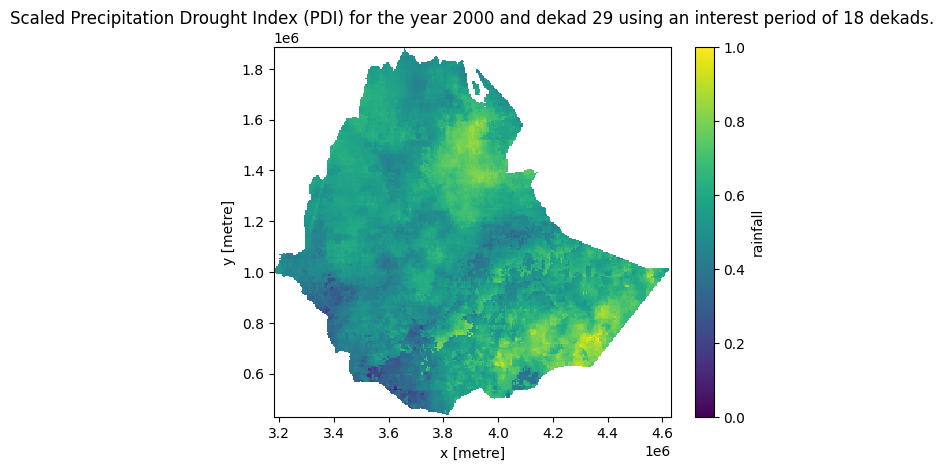

In [14]:
PDI.plot()
plt.title(f"Scaled Precipitation Drought Index (PDI) for the year {y} and dekad {d} using an interest period of {ip} dekads.");